# CS7324 - Spring 2026 - Lab 5

* Group xx: Kristoffer Matsson, Arturo Perez Espinosa, Mike Truty
* Due: Sun 2026-04-19

## Grading Rubric

### 1. Preparation (4 points total)

* [1 points] Define and prepare your class variables. Use proper variable representations (int, float, one-hot, etc.). Use pre-processing methods (as needed) for dimensionality reduction, scaling, etc. Remove variables that are not needed/useful for the analysis. Describe the final dataset that is used for classification/regression (include a description of any newly formed variables you created). You have the option of using tf.dataset for processing, but it is not required. 
* [1 points] Identify groups of features in your data that should be combined into cross-product features. Provide a compelling justification for why these features should be crossed (or why some features should not be crossed). 
* [1 points] Choose and explain what metric(s) you will use to evaluate your algorithm’s performance. You should give a detailed argument for why this (these) metric(s) are appropriate on your data. That is, why is the metric appropriate for the task (e.g., in terms of the business case for the task). Please note: rarely is accuracy the best evaluation metric to use. Think deeply about an appropriate measure of performance.
* [1 points] Choose the method you will use for dividing your data into training and testing (i.e., are you using Stratified 10-fold cross validation? Shuffle splits? Why?). Explain why your chosen method is appropriate or use more than one method as appropriate. Argue why your cross validation method is a realistic mirroring of how an algorithm would be used in practice. Use the method to split your data that you argue for. 

### 2. Modeling (5 points total)

* [2 points] Create at least three combined wide and deep networks to classify your data using Keras (this total of "three" includes the model you will train in the next step of the rubric). Visualize the performance of the network on the training data and validation data in the same plot versus the training iterations.
  * Note: you can use the "history" return parameter that is part of Keras "fit" function to easily access this data.
* [2 points] Investigate generalization performance by altering the number of layers in the deep branch of the network. Try at least two models (this "two" includes the wide and deep model trained from the previous step). Use the method of cross validation and evaluation metric that you argued for at the beginning of the lab to answer: What model with what number of layers performs superiorly? Use proper statistical methods to compare the performance of different models.
* [1 points] Compare the performance of your best wide and deep network to a standard multi-layer perceptron (MLP). Alternatively, you can compare to a network without the wide branch (i.e., just the deep network). For classification tasks, compare using the receiver operating characteristic and area under the curve. For regression tasks, use Bland-Altman plots and residual variance calculations.  Use proper statistical methods to compare the performance of different models.  

### 3. Exceptional Work (1 points total)

* 5000 students: You have free reign to provide additional analyses.
* One idea (required for 7000 level students): Capture the embedding weights from the deep network and (if needed) perform dimensionality reduction on the output of these embedding layers (only if needed). That is, pass the observations into the network, save the embedded weights (called embeddings), and then perform  dimensionality reduction in order to visualize results. Visualize and explain any clusters in the data.


In [15]:
#import libraries

import kagglehub
import pandas as pd
import numpy as np
import os

## Data Import - from Kaggle

We selected a `canada-housing` dataset from Kaggle. 

In [16]:
# retrieve the path to the csv file 
kaggle_path = kagglehub.dataset_download("yuliiabulana/canada-housing")
print(f"Path to dataset files: {kaggle_path}")

file_name = "cleaned_canada.csv"
file_path = os.path.join(kaggle_path, file_name)
print(f"Selected file: {file_path}")

Using Colab cache for faster access to the 'canada-housing' dataset.
Path to dataset files: /kaggle/input/canada-housing
Selected file: /kaggle/input/canada-housing/cleaned_canada.csv


In [17]:
# Read the data and study the data types and missing values
df_raw = pd.read_csv(file_path)

print(df_raw.shape)

summary = df_raw.count().rename("non_nan_count").to_frame()
summary["nan_count"] = len(df_raw) - summary["non_nan_count"]
summary

(44896, 23)


,non_nan_count,nan_count
City,44896,0
Province,44896,0
Latitude,44896,0
Longitude,44896,0
Price,44896,0
Bedrooms,44896,0
Bathrooms,44896,0
Acreage,44896,0
Property Type,44896,0
Square Footage,44896,0


### Data shape

The raw data set is ~45k rows x 23 columns/features.
We'd prefer to avoid trying to model with features/columns with missing data.
We'll drop columns which have significant missing data. We chose: Basement,
Exterior, Heating, Flooring, and Roof since they all have many NaN values.
Overall, we're standardizing our model on homes in which one family might reside.
This will exclude lots, and multi-family homes. It will include studios, 1+ bedroom homes,
condos, and townhouses.

In [18]:
# Drop the columns which seem to have a lot of missing values and are not likely to be useful for modeling.
drop_columns = ['Basement', 'Exterior', 'Heating', 'Flooring', 'Roof']
df_no_nan = df_raw.drop(columns = drop_columns)
df_no_nan.dropna(inplace = True)
df_no_nan

,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,Garage,Parking,Fireplace,Waterfront,Sewer,Pool,Garden,Balcony
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,Yes,Yes,No,No,municipal,No,No,No
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,Yes,Yes,No,No,septic,No,No,No
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,No,No,No,No,municipal,No,No,No
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,Yes,No,Yes,No,municipal,No,No,No
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,Yes,Yes,No,No,none,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44891,Fort Nelson,BC,58.805426,-122.691717,289000.0,3.0,3.0,0.15,Single Family,2175.0,Yes,No,No,No,none,No,No,No
44892,La Crete,AB,58.184661,-116.421516,350000.0,4.0,3.0,0.23,Single Family,1056.0,Yes,Yes,No,No,none,No,Yes,No
44893,High Level,AB,58.517660,-117.143173,270000.0,4.0,2.0,0.22,Single Family,1075.0,Yes,Yes,Yes,No,none,No,No,No
44894,Whitehorse,YT,60.698432,-135.117177,749000.0,4.0,3.0,0.19,Single Family,2576.0,No,No,Yes,No,none,No,No,No


### Data cleaning

We think some of the property types won't make sense in our model for determining home prices.
Let's explore...

Below, we'll remove anything that doesn't really seem like a single-family-home.
We think the following should remain: "Single Family", "Condo", "Townhome", "Condo/Townhome".

Property Type
Single Family        26619
Condo                12593
Townhome              2237
Condo/Townhome        1655
Duplex                1056
MultiFamily            281
Mobile Home            228
Manufactured Home      211
Vacant Land             16
Name: count, dtype: int64


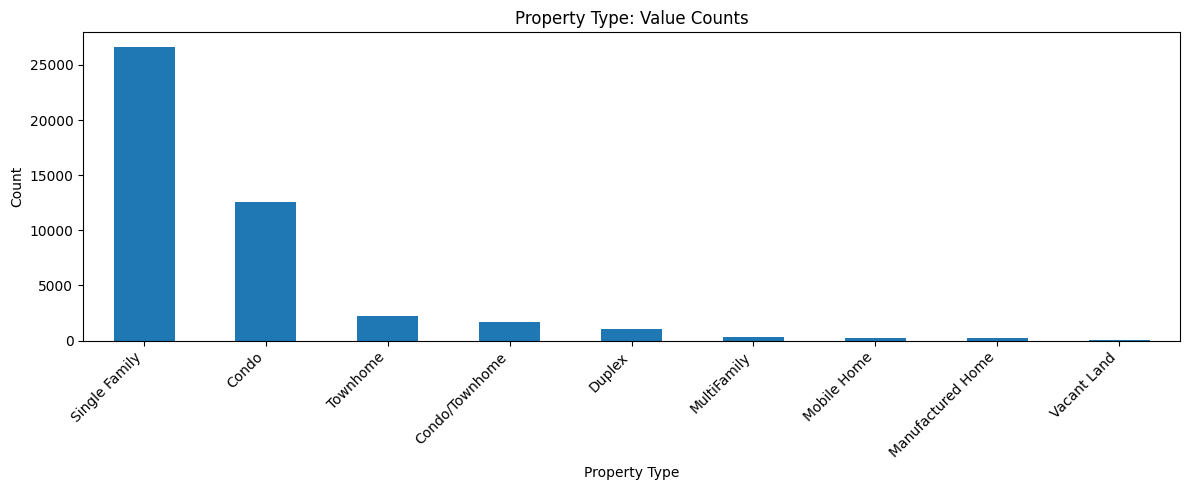

In [19]:
import matplotlib.pyplot as plt

property_type_counts = df_no_nan['Property Type'].value_counts(dropna=False).sort_values(ascending=False)
print(property_type_counts)

plt.figure(figsize=(12, 5))
property_type_counts.plot(kind='bar')
plt.title('Property Type: Value Counts')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Remove anything that is not: ["Single Family", "Condo", "Townhome", "Condo/Townhome"]
df_no_nan = df_no_nan[df_no_nan['Property Type'].isin(["Single Family", "Condo", "Townhome", "Condo/Townhome"])]
print(df_no_nan.shape)  

(43104, 18)


This dropped us from 44896 to 43104 rows, still with 18 columns, including our output: Price.

The other benefit here is this likely removed some other data that was likely marginalized.
For example, we know there were 439 rows where "Bedrooms" was actually 0.0.
Now there are 415.

But, Bedrooms = 0 might just be code for "studio", which is possible. The more concerning would be
Bathrooms = 0; what does that mean? Acreage = 0 could just be code for apartment/condo?

In [21]:
print((df_no_nan["Bedrooms"] <= 0.0).sum())
zero_bedrooms_rows = df_no_nan.loc[df_no_nan["Bedrooms"] == 0.0].copy()

print(f"Rows with Bedrooms = 0.0: {len(zero_bedrooms_rows)}")
display(zero_bedrooms_rows)

415
Rows with Bedrooms = 0.0: 415


,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,Garage,Parking,Fireplace,Waterfront,Sewer,Pool,Garden,Balcony
179,Big White,BC,49.721928,-118.925423,205000.0,0.0,1.0,0.00,Condo,462.0,No,Yes,No,No,municipal,No,No,No
207,Langley,BC,49.157610,-122.657681,589900.0,0.0,1.0,0.00,Condo,791.0,Yes,Yes,Yes,No,none,No,No,No
224,Surrey,BC,49.190813,-122.826820,409900.0,0.0,1.0,0.00,Condo,383.0,Yes,Yes,No,No,none,No,No,No
397,Coquitlam,BC,49.285773,-122.795780,624900.0,0.0,2.0,0.00,Condo,996.0,Yes,Yes,No,No,none,No,No,No
450,Vancouver,BC,49.251826,-123.237580,758800.0,0.0,1.0,0.00,Condo,471.0,Yes,Yes,No,No,none,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44175,Prince Albert,SK,53.199628,-105.801147,799900.0,0.0,0.0,0.00,Single Family,840.0,Yes,No,No,No,none,No,No,No
44639,Saskatoon,SK,52.117692,-106.682691,89900.0,0.0,0.0,0.07,Single Family,670.0,No,No,No,No,none,No,No,No
44670,Saskatoon,SK,52.133867,-106.671592,260000.0,0.0,2.0,0.14,Single Family,2360.0,No,Yes,No,No,none,No,No,No
44671,Saskatoon,SK,52.123927,-106.678563,105000.0,0.0,1.0,0.07,Single Family,338.0,No,Yes,No,No,none,No,No,No


We notice here that Bedrooms, Bathrooms, and Acreage can all be 0.00.
This is likely because some properties are listed as "Studio" or "Loft"
(which may have 0 bedrooms) or "Condo/Townhome" (which may have 0 acreage).


### Data output

We intend to use `Price` as our output class. We decided to attempt building a regression model here which
could predict a **price** for a home given input criteria.

We still have >43k rows with 17 feature columns, categorical and numeric. We should be good.

In [22]:
# show the dtypes
df_no_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43104 entries, 0 to 44895
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            43104 non-null  object 
 1   Province        43104 non-null  object 
 2   Latitude        43104 non-null  float64
 3   Longitude       43104 non-null  float64
 4   Price           43104 non-null  float64
 5   Bedrooms        43104 non-null  float64
 6   Bathrooms       43104 non-null  float64
 7   Acreage         43104 non-null  float64
 8   Property Type   43104 non-null  object 
 9   Square Footage  43104 non-null  float64
 10  Garage          43104 non-null  object 
 11  Parking         43104 non-null  object 
 12  Fireplace       43104 non-null  object 
 13  Waterfront      43104 non-null  object 
 14  Sewer           43104 non-null  object 
 15  Pool            43104 non-null  object 
 16  Garden          43104 non-null  object 
 17  Balcony         43104 non-null  obje

As demonstrated above, all features which were originally made up of string data have been converted to unique integers. This ensures that the data is all numeric and will still allow the use of embedding or one hot encoding later in the notebook.

There are no new features added to the dataset. So far, we have only cleaned up the data and modified the string data to be integers. 

We believe that all of the features shown above are of value and should be kept for the model. Although we originally wanted to drop the latitude and longitude features since we already have 'City' and 'Province' to cover geographic characters, we believe those two features would be useful for the model to characterize expensive neighborhoods or homes in which its price is heavily driven by a special location in a city. 

## Pre-processing

In [35]:
# Let's divide our 18 columns of data into: target (price), then features:
#     categorical, discretized, and numeric.
# We will use the categorical features to create crossed features for the wide branch of our model,
# and we will use the numeric features in the deep branch of our model.
# The categorical features will also be used in the deep branch of our model as well.

# In general, to use TensorFlow/Keras, need feature names to NOT include spaces.
# For example:
# "Property Type" -> "Property_Type"
# "Square Footage_bin" -> "Square_Footage_bin"
safe_name_map = {
    c: (
        c.strip()
         .replace(" ", "_")
         .replace("/", "_")
         .replace("-", "_")
    )
    for c in df_no_nan.columns
}
df_model = df_no_nan.rename(columns=safe_name_map)

target_col = "Price"
feature_cols = sorted([c for c in df_model.columns if c != target_col])

# Identify categorical columns by their type.
categorical_headers = [
    c for c in feature_cols
    if c in df_model.select_dtypes(include=["object", "category", "string"]).columns
]

# Everything else is numeric after preprocessing
numeric_headers = [c for c in feature_cols if c not in categorical_headers]

# We can discretized a few numeric columns since that seems to both improve performance
# and make these features more useful for crossing in the wide branch of our model.
discretized_source_headers = sorted([c for c in ["Square_Footage", "Acreage"] if c in numeric_headers])
discretized_headers = [f"{c}_bin" for c in discretized_source_headers]

continuous_numeric_headers = [c for c in numeric_headers if c not in discretized_source_headers]

print(f"Target: {target_col}")
print(f"Categorical: {categorical_headers}")
print(f"Discretized: {discretized_headers}")
print(f"Continuous numeric: {continuous_numeric_headers}")

Target: Price
Categorical: ['Balcony', 'City', 'Fireplace', 'Garage', 'Garden', 'Parking', 'Pool', 'Property_Type', 'Province', 'Sewer', 'Waterfront']
Discretized: ['Acreage_bin', 'Square_Footage_bin']
Continuous numeric: ['Bathrooms', 'Bedrooms', 'Latitude', 'Longitude']


### Split data first, then derive discretized features

We first separate features from the target and create a **70/15/15** train/validation/test split.
Because this is a regression problem, we stratify using **price quantile bins** so each partition contains a reasonable spread of lower-, middle-, and higher-priced homes.

Doing the split **before** learning bin edges or normalization statistics helps reduce leakage from the validation and test sets into training.

In [43]:
from sklearn.model_selection import train_test_split

# Split BEFORE learning any discretization bins or preprocessing statistics.
X = df_model.drop(columns=["Price"]).copy()
y = df_model["Price"].astype("float32").copy()

# Use price quantile bins only for stratification so each split has a similar
# spread of low-, mid-, and high-priced homes.
price_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

# First split off 30% of the data for validation and test,
# then split that temp partition in half to get 15% val and 15% test.
X_train, X_temp, y_train, y_temp, bins_train, bins_temp = train_test_split(
    X,
    y,
    price_bins,
    test_size=0.30,
    random_state=42,
    stratify=price_bins,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=bins_temp,
)

print(f"Train rows: {len(X_train)} ({len(X_train)/len(X):.1%})")
print(f"Validation rows: {len(X_val)} ({len(X_val)/len(X):.1%})")
print(f"Test rows: {len(X_test)} ({len(X_test)/len(X):.1%})")


Train rows: 30172 (70.0%)
Validation rows: 6466 (15.0%)
Test rows: 6466 (15.0%)


In [47]:
# This is sort of advanced. We want to use quantiles for these numeric features,
# but we want to learn the quantile bin edges ONLY from the training split so that the
# holdout validation and test partitions remain truly unseen.

# Learn quantile bin edges ONLY from the training split, then apply those same
# edges to validation and test so the holdout partitions remain truly unseen.
for col in discretized_source_headers:
    _, bin_edges = pd.qcut(
        X_train[col],
        q=20,
        labels=False,
        retbins=True,
        duplicates="drop",
    )
    bin_edges = np.unique(bin_edges)
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    X_train[f"{col}_bin"] = pd.cut(
        X_train[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")
    X_val[f"{col}_bin"] = pd.cut(
        X_val[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")
    X_test[f"{col}_bin"] = pd.cut(
        X_test[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")

# Keep only the binned versions for these features in each split.
for split_df in (X_train, X_val, X_test):
    split_df.drop(columns=discretized_source_headers, inplace=True)


In [44]:
# We also want Bedrooms and Bathrooms available as coarse CATEGORICAL bins for
# the wide branch. These bins are rule-based, and we can then apply the same mapping
# consistently across train/validation/test data. We also want to be sure to handle
# any non-numeric values or missing values in these columns by treating them as 0.0
# (which will then fall into the lowest bin).

bedrooms_zero_count = (X_train["Bedrooms"] == 0.0).sum()
bathrooms_zero_count = (X_train["Bathrooms"] == 0.0).sum()
print(f'Count of X_train["Bedrooms"] == 0.0: {bedrooms_zero_count}')
print(f'Count of X_train["Bathrooms"] == 0.0: {bathrooms_zero_count}')

for split_df in (X_train, X_val, X_test):
    bedrooms_num = pd.to_numeric(split_df["Bedrooms"], errors="coerce")
    bedrooms_num = bedrooms_num.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    split_df["Bedrooms_bin"] = pd.cut(
        bedrooms_num,
        bins=[-np.inf, 0, 1, 2, 3, 4, 5, np.inf],
        labels=False,
        include_lowest=True,
    ).astype("int64")

    bathrooms_num = pd.to_numeric(split_df["Bathrooms"], errors="coerce")
    bathrooms_num = bathrooms_num.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    split_df["Bathrooms_bin"] = pd.cut(
        bathrooms_num,
        bins=[-np.inf, 0, 1, 2, 3, 4, 5, np.inf],
        labels=False,
        include_lowest=True,
    ).astype("int64")


Count of X_train["Bedrooms"] == 0.0: 279
Count of X_train["Bathrooms"] == 0.0: 175


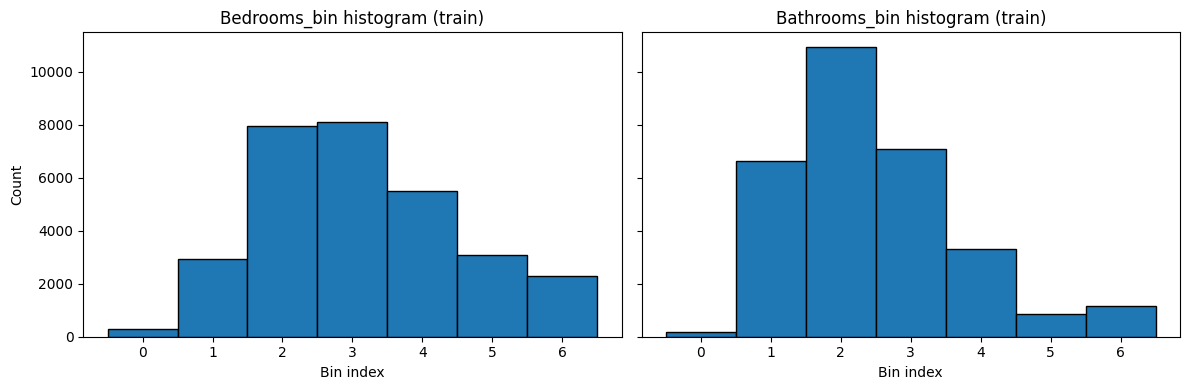

In [45]:
# Visualize the training-set distributions of the new bedroom/bathroom bins.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, col in zip(axes, ["Bedrooms_bin", "Bathrooms_bin"]):
    vals = X_train[col].dropna().astype(int)
    lo, hi = vals.min(), vals.max()
    edges = np.arange(lo - 0.5, hi + 1.5, 1)

    ax.hist(vals, bins=edges, edgecolor="black")
    ax.set_xticks(np.arange(lo, hi + 1))
    ax.set_xlabel("Bin index")
    ax.set_title(f"{col} histogram (train)")

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [49]:
# Bin latitude/longitude using training-derived quantile edges so we can cross
# them as a proxy for neighborhood/location effects.
for col in ["Latitude", "Longitude"]:
    _, bin_edges = pd.qcut(
        X_train[col], q=30, labels=False, retbins=True, duplicates="drop"
    )
    bin_edges = np.unique(bin_edges)
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    X_train[f"{col}_bin"] = pd.cut(
        X_train[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")
    X_val[f"{col}_bin"] = pd.cut(
        X_val[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")
    X_test[f"{col}_bin"] = pd.cut(
        X_test[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")

### Review split sizes

The dataset has now been partitioned into **training**, **validation**, and **test** sets.
The validation set is used during model development and tuning, while the test set is kept as a final holdout for unbiased evaluation.

In [42]:
split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(X_train), len(X_val), len(X_test)],
        "pct_of_total": [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
        "price_mean": [y_train.mean(), y_val.mean(), y_test.mean()],
        "price_median": [y_train.median(), y_val.median(), y_test.median()],
        "price_min": [y_train.min(), y_val.min(), y_test.min()],
        "price_max": [y_train.max(), y_val.max(), y_test.max()],
    }
)

split_summary["pct_of_total"] = split_summary["pct_of_total"].map(lambda v: f"{v:.1%}")
display(split_summary)


,split,rows,pct_of_total,price_mean,price_median,price_min,price_max
0,train,30172,70.0%,1072216.875,685400.0,50000.0,32000000.0
1,validation,6466,15.0%,1070186.750,686000.0,50000.0,58800000.0
2,test,6466,15.0%,1068150.750,686200.0,50000.0,49800000.0


### Final split analysis

We used a simple **train/validation/test holdout split** stratified on **price quantile bins**. This approach was appropriate because the dataset is fairly large at about **43,000 rows**, so each partition still contains plenty of observations across the range of home prices.

We did not use full cross-validation because it would add substantial computational cost while offering limited practical benefit for a dataset of this size. We also did not rely on repeated shuffle splits, since a single stratified holdout already gives a representative spread of price points in each partition and is easier to explain and reproduce.

In [61]:
# Now set up the 5 crossed features we want to create for the wide branch of our model.
cross_pairs = [
    ("City", "Property_Type"),
    ("City", "Square_Footage_bin"),
    ("Province", "Property_Type"),
    ("Bedrooms_bin", "Bathrooms_bin"),
    ("Latitude_bin", "Longitude_bin"),
]

# Compute data-driven crossing dimensions.
# We size each hash space from observed pair cardinality, capped by theoretical max.
rows = []
for a, b in cross_pairs:
    n_a = X_train[a].nunique(dropna=True)
    n_b = X_train[b].nunique(dropna=True)
    theoretical_max = int(n_a * n_b)
    observed_pairs = int(X_train[[a, b]].drop_duplicates().shape[0])

    suggested_dim = int(min(theoretical_max, max(32, np.ceil(observed_pairs * 1.5))))

    rows.append(
        {
            "pair": (a, b),
            "n_unique_a": int(n_a),
            "n_unique_b": int(n_b),
            "theoretical_max": theoretical_max,
            "observed_pairs": observed_pairs,
            "selected_crossing_dim": suggested_dim,
        }
    )

cross_stats = pd.DataFrame(rows)
display(cross_stats)

# Keys match cross_pairs and are used by FeatureSpace.cross below.
cross_dims = {
    row["pair"]: int(row["selected_crossing_dim"])
    for _, row in cross_stats.iterrows()
}

print("selected cross_dims =")
for k, v in cross_dims.items():
    print(f"  {k}: {v}")

,pair,n_unique_a,n_unique_b,theoretical_max,observed_pairs,selected_crossing_dim
0,"(City, Property_Type)",2633,4,10532,3059,4589
1,"(City, Square_Footage_bin)",2633,20,52660,7550,11325
2,"(Province, Property_Type)",11,4,44,37,44
3,"(Bedrooms_bin, Bathrooms_bin)",7,7,49,47,49
4,"(Latitude_bin, Longitude_bin)",30,30,900,382,573


selected cross_dims =
  ('City', 'Property_Type'): 4589
  ('City', 'Square_Footage_bin'): 11325
  ('Province', 'Property_Type'): 44
  ('Bedrooms_bin', 'Bathrooms_bin'): 49
  ('Latitude_bin', 'Longitude_bin'): 573


### Cross-pairing explanation

We selected crossed features, for the wide branch, where we believed the **combination** of two variables
would carry more pricing information than either variable alone.

- **City × Property Type:** the value of a condo, townhome, or single-family home can differ substantially from city to city.
- **City × Square Footage bin:** the effect of home size changes across markets, since a larger home
  in a high-cost city might show a premium vs a similarly sized home elsewhere.
- **Province × Property Type:** there might be broader regional pricing differences across provinces.
- **Bedrooms bin × Bathrooms bin:** these jointly describe the functional layout of a home BETTER
  than either count in isolation.
- **Latitude bin × Longitude bin:** TOGETHER these act as a neighborhood-level location,
  which is especially important in housing data where price is heavily influenced by location.

We limited crossings to this small set of pairs so the model might capture meaningful interactions
without creating an unnecessarily large or noisy feature space.

#### How many Crossed Feature dimensions?

For the hashed crossing DIMENSIONS, we chose a value between the observed number of unique pairings
in the training data and the theoretical maximum possible number of pairings.
In practice, we used about **1.5 × the observed number of pairs**, capped by the theoretical maximum.

The final dimensions seems reasonable, but two of them are quite large. It will be interesting to see
how this affects the model, and any embeddings.

We wondered how these dimensions were used/populated for each crossed pair. These
crossed feature pairs are implemented using Keras feature crosses, which hash each
observed pair into a fixed integer space. These hashed cross-indices are then
passed through embedding layers so the network can learn compact representations
of thee important feature interactions.

In [63]:
# From 10a. Keras Wide and Deep as TFData.ipynb.
#
# Finally, set up the Keras preprocessing layers for the crossed features, categorical features,
# and numeric features.
#
# Use the Keras FeatureSpace utility to manage all of the preprocessing for us,
# including learning normalization parameters from the training data and applying
# the same transformations to the test data.

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

from sklearn import metrics as mt
import tensorflow as tf
from tensorflow import keras

print(tf.__version__)
print(keras.__version__)


2.19.0
3.13.2


In [65]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

from tensorflow.keras.layers import Dense, Activation, Input, Dropout
from tensorflow.keras.layers import Embedding, Concatenate, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

from tensorflow.keras.utils import FeatureSpace

# Crossing columns together 
feature_space = FeatureSpace(
    features={
        # Categorical feature encoded as string. 11 of these.
        "Balcony":       FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "City":          FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Fireplace":     FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Garage":        FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Garden":        FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Parking":       FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Pool":          FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Property_Type": FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Province":      FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Sewer":         FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Waterfront":    FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),

        # Our discretized numeric features that we want to treat as categorical for crossing and
        # also in the deep branch.  6 of these.
        "Acreage_bin":        FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Bathrooms_bin":      FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Bedrooms_bin":       FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Latitude_bin":       FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Longitude_bin":      FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Square_Footage_bin": FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        
        # Numerical features to normalize (normalization will be learned)
        # learns the mean, variance, and if to invert (3 parameters)
        # 4 of these.
        "Bathrooms": FeatureSpace.float_normalized(),
        "Bedrooms":  FeatureSpace.float_normalized(),
        "Latitude":  FeatureSpace.float_normalized(),
        "Longitude": FeatureSpace.float_normalized(),
    },
    # Specify feature cross with a custom crossing dim
    crosses=[
        FeatureSpace.cross(
            feature_names=pair,
            crossing_dim=cross_dims[pair],
            output_mode="int",
        )
        for pair in cross_pairs
    ],
    output_mode="dict",
)

### Set up Tensorflow tf.data

In this section, we build TensorFlow datasets that feed tensors to the model.

We convert the split pandas dataframes into TensorFlow input pipelines for:
* training
* validation
* testing

Each dataset includes a dictionary of input features and a target variable, Price for each modeled input.
They become `tf.data` datasets. These pipelines supply batches of feature tensors and target values
during model training and evaluation. We shuffle only the training data, and the runtime
prefetches batches for performance.

In [66]:
# Now create tf.data datasets for training, validation, and final holdout testing.
batch_size = 256

ds_train = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train.values))
ds_train = ds_train.shuffle(len(X_train), seed=42).batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((dict(X_val), y_val.values))
ds_val = ds_val.batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_test = tf.data.Dataset.from_tensor_slices((dict(X_test), y_test.values))
ds_test = ds_test.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [67]:
# Learn preprocessing parameters from the training data only, then apply the
# exact same transforms to validation and test.
train_ds_with_no_labels = ds_train.map(lambda x, _: x)

# ADAPT is the key method that learns normalization parameters
# for numeric features and learns the unique values for
# categorical features (which are needed for hashing and crossing).
# We only adapt on the training data so that the validation and test data remain unseen.
feature_space.adapt(train_ds_with_no_labels)

preprocessed_ds_train = ds_train.map(
    lambda x, y: (feature_space(x), y), num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

preprocessed_ds_val = ds_val.map(
    lambda x, y: (feature_space(x), y), num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

preprocessed_ds_test = ds_test.map(
    lambda x, y: (feature_space(x), y), num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)


### Set up Embeddings

In [69]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

# Features are encoded as integers and normalized floats.
# We use embeddings to deal with the integer-encoded features
# as if they were one-hot encoded, which allows us to use them
# in the wide branch of our model without blowing up the dimensionality.

def setup_embedding_from_encoding_crossing(encoded_features, feature_space, col_name):
    # get the size of the feature
    x = encoded_features[col_name]
    # get the size of the feature
    N = feature_space.crossers[col_name].num_bins
    N_embed = int(np.sqrt(N))
    print(f'Crossing: {col_name} from {N} OHE to {N_embed} features.')
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_embed, 
                  name=col_name+'_embed')(x)
    return  Flatten()(x) # get rid of that pesky extra dimension (for time of embedding)

def setup_embedding_from_encoding_categorical(encoded_features, feature_space, col_name):
    # get the size of the feature
    x = encoded_features[col_name]
    # get the size of the feature
    N = len(feature_space.preprocessors[col_name].get_vocabulary())
    N_embed = int(np.sqrt(N))
    
    print(f'Category Embed: {col_name} from {N} OHE to {N_embed} features.')
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_embed, 
                  name=col_name+'_embed')(x)
    return Flatten()(x) # get rid of that pesky extra dimension (for time of embedding)

dict_inputs = feature_space.get_inputs() # need to use unprocessed features here, to gain access to each output
encoded_feature_tensors = feature_space.get_encoded_features() # these features have been encoded

# Build explicitly named encoded inputs so dict keys match tensor names exactly.
encoded_features = {
    col: keras.Input(
        shape=tensor.shape[1:],
        dtype=tensor.dtype,
        name=col
    )
    for col, tensor in encoded_feature_tensors.items()
}

# Only keep numeric headers that are still present after discretization.
numeric_deep_headers = [col for col in continuous_numeric_headers if col in encoded_features]

# we need to create separate lists for each branch: the wide branch will
# use the crossed features, and the deep branch will use the numeric
# features and categorical features (after embedding).
crossed_outputs = []

# for each crossed variable, make an embedding
for col in feature_space.crossers.keys():
    x = setup_embedding_from_encoding_crossing(encoded_features, feature_space, col)
    
    # save these outputs in list to concatenate later
    crossed_outputs.append(x)

# now concatenate the outputs and add a fully connected layer
wide_branch = Concatenate(name='wide_concat')(crossed_outputs)

# reset this input branch
all_deep_branch_outputs = []

# for each numeric variable, just add it in after embedding
for col in numeric_deep_headers:
    x = encoded_features[col]
    all_deep_branch_outputs.append(x)
    
# for each categorical variable
for col in categorical_headers:
    # get the output tensor from ebedding layer
    x = setup_embedding_from_encoding_categorical(encoded_features,feature_space, col)
    
    # save these outputs in list to concatenate later
    all_deep_branch_outputs.append(x)

# Ensure every declared encoded input is connected to the graph.
used_feature_keys = set(feature_space.crossers.keys()) | set(numeric_deep_headers) | set(categorical_headers)
for col in sorted(encoded_features.keys()):
    if col not in used_feature_keys:
        all_deep_branch_outputs.append(encoded_features[col])

Crossing: City_X_Property_Type from 4589 OHE to 67 features.
Crossing: City_X_Square_Footage_bin from 11325 OHE to 106 features.
Crossing: Province_X_Property_Type from 44 OHE to 6 features.
Crossing: Bedrooms_bin_X_Bathrooms_bin from 49 OHE to 7 features.
Crossing: Latitude_bin_X_Longitude_bin from 573 OHE to 23 features.
Category Embed: Balcony from 3 OHE to 1 features.
Category Embed: City from 2634 OHE to 51 features.
Category Embed: Fireplace from 3 OHE to 1 features.
Category Embed: Garage from 3 OHE to 1 features.
Category Embed: Garden from 3 OHE to 1 features.
Category Embed: Parking from 3 OHE to 1 features.
Category Embed: Pool from 3 OHE to 1 features.
Category Embed: Property_Type from 5 OHE to 2 features.
Category Embed: Province from 12 OHE to 3 features.
Category Embed: Sewer from 6 OHE to 2 features.
Category Embed: Waterfront from 3 OHE to 1 features.


### Analysis

This is pretty cool. We now have a number of interesting features, including
these crossed features which may be more useful signals for Price.

Notice how the dimensionality for the OHE features is significantly
lower than it would have been.

## Choosing our Metrics for Algorithm performance

We will evaluate our regression model with **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**. MAE gives an human-visible
measure of the average dollar error in the predictions, while RMSE shows a larger penalty on large mistakes.
This is important in housing-price prediction, where very large overestimates or underestimates can be especially costly,
to buyers and sellers.

We do **not** use `accuracy`, `precision`, or `recall` because those metrics are designed for **classification**
problems with discrete class labels, whereas our target is a continuous numeric price.

In addition to MAE and RMSE, we will use a **Bland–Altman plot** to visualize agreement
between the predicted prices and the true prices. This plot helps show whether the
model tends to overpredict or underpredict and whether the prediction errors
become larger at certain price ranges. That makes it a useful complement to
summary metrics, since it reveals patterns in the residuals that a single number alone might hide.

## Modeling

### Model 1: wide and deep with crossed-features


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Balcony             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Property_Type       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Province            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Sewer (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Waterfront          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Balcony_embed       │ (None, 1, 1)      │          3 │ Balcony[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City_embed          │ (None, 1, 51)     │    134,334 │ City[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace_embed     │ (None, 1, 1)      │          3 │ Fireplace[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage_embed        │ (None, 1, 1)      │          3 │ Garage[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden_embed        │ (None, 1, 1)      │          3 │ Garden[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking_embed       │ (None, 1, 1)      │          3 │ Parking[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool_embed          │ (None, 1, 1)      │          3 │ Pool[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,661,667 (6.34 MB)

 Trainable params: 1,661,667 (6.34 MB)

 Non-trainable params: 0 (0.00 B)

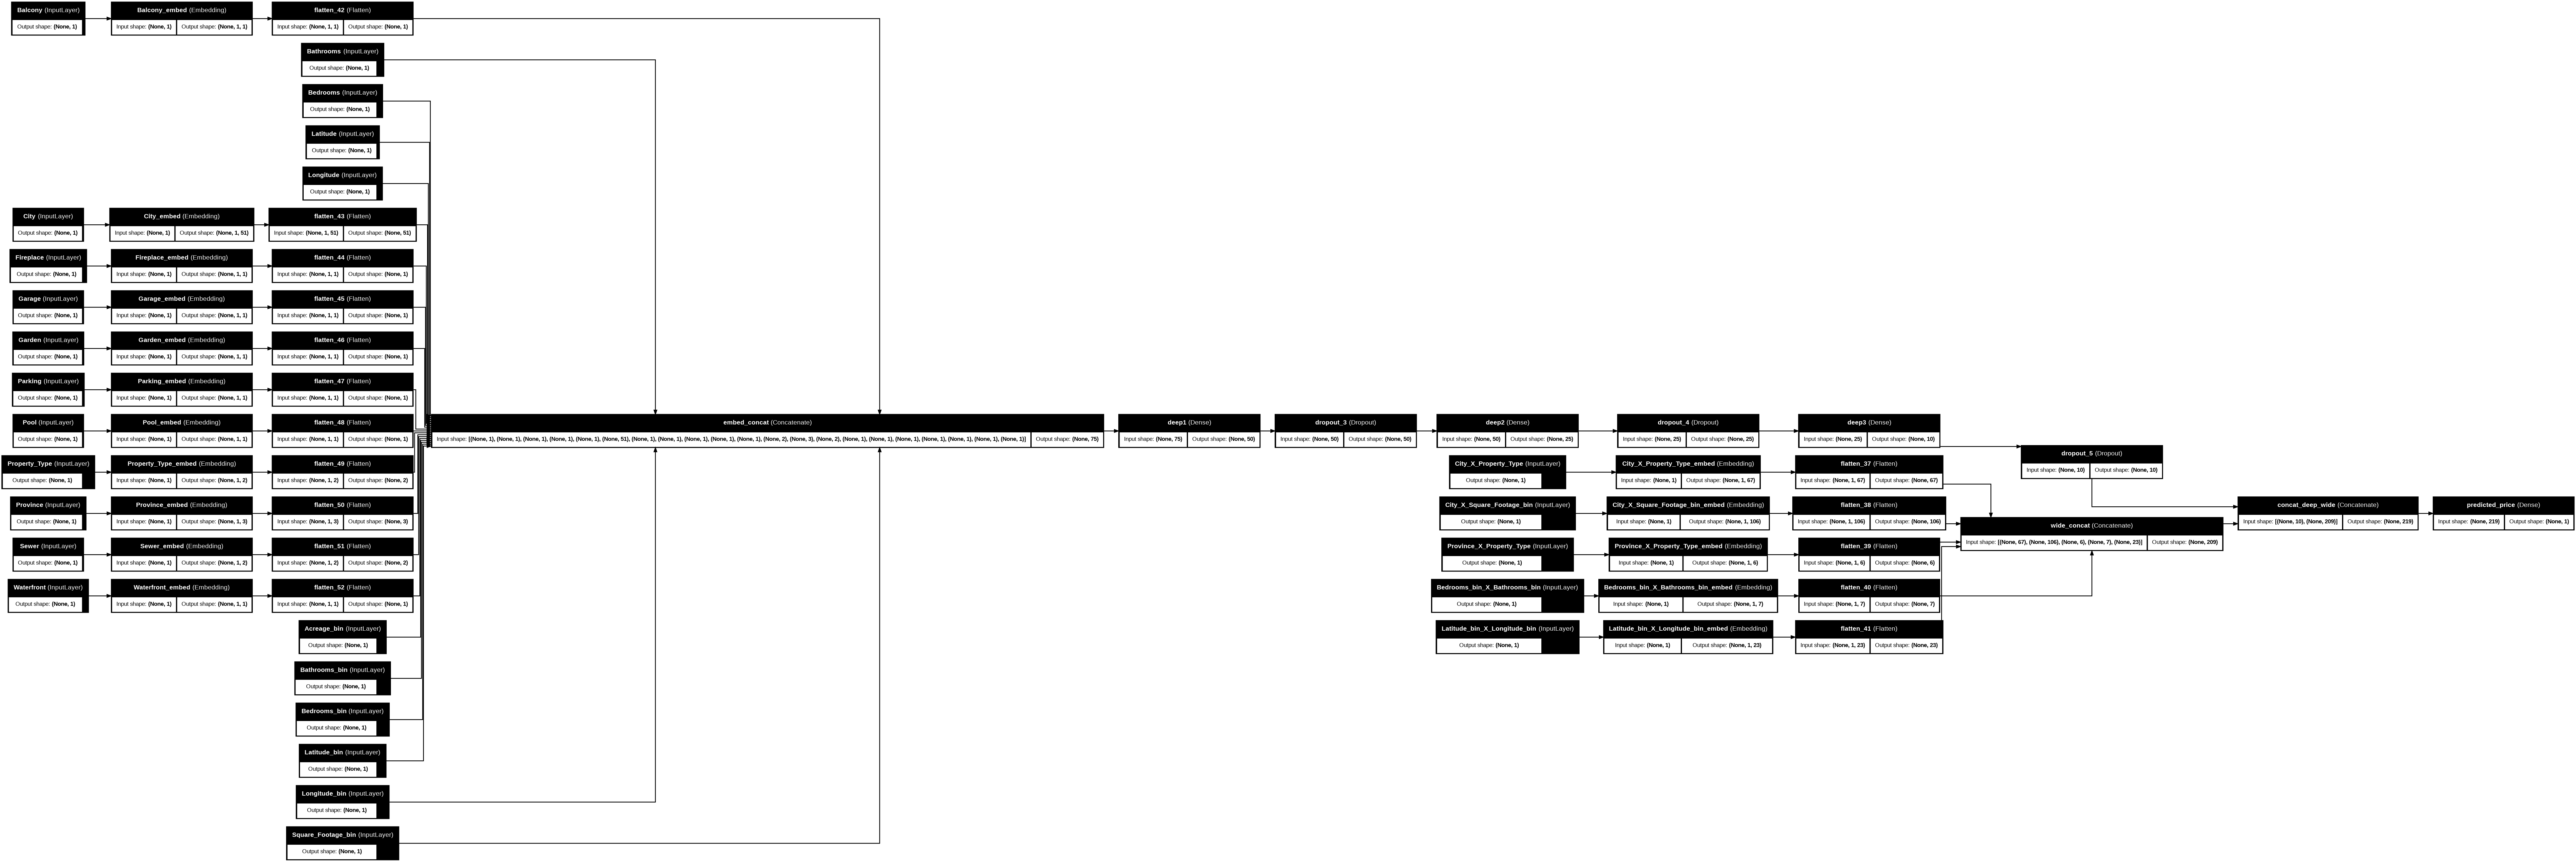

In [70]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

# merge the deep branches together
deep_branch = Concatenate(name='embed_concat')(all_deep_branch_outputs)
deep_branch = Dense(units=50,activation='relu', name='deep1')(deep_branch)
deep_branch = Dropout(0.6)(deep_branch)
deep_branch = Dense(units=25,activation='relu', name='deep2')(deep_branch)
deep_branch = Dropout(0.4)(deep_branch)
deep_branch = Dense(units=10,activation='relu', name='deep3')(deep_branch)
deep_branch = Dropout(0.2)(deep_branch)
    
# merge the deep and wide branch
final_branch = Concatenate(name='concat_deep_wide')([deep_branch, wide_branch])

# Now final output for regression uses linear activation, not sigmoid.
final_branch = Dense(units=1, activation='linear',
                     name='predicted_price')(final_branch)

# encoded features input, fast
training_model = keras.Model(inputs=encoded_features, outputs=final_branch)

# Uses MSE loss for regression, and tracks MAE and RMSE as metrics,
# whereas before this used binary crossentropy loss and accuracy metrics for classification.
training_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")]
 )

training_model.summary()

# non-encoded: use the encoded tensors that are already connected to dict_inputs
inference_output = training_model(encoded_feature_tensors)
inference_model = keras.Model(inputs=dict_inputs, outputs=inference_output)
inference_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")]
 )


plot_model(
    training_model, to_file='model.png', show_shapes=True, show_layer_names=True,
    rankdir='LR', expand_nested=False, dpi=96
)

In [71]:
# Re-compile before fit to ensure a fresh optimizer state after graph/name edits.
# Tune against the validation set; keep the test set as a final holdout only.
training_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mse",
    metrics=[
        "mae",
        keras.metrics.RootMeanSquaredError(name="rmse"),
    ]
)

history = training_model.fit(
    preprocessed_ds_train,
    epochs=30,
    validation_data=preprocessed_ds_val,
    verbose=2,
)

Epoch 1/30
118/118 - 11s - 97ms/step - loss: 3219987103744.0000 - mae: 1072102.1250 - rmse: 1794432.2500 - val_loss: 3402417569792.0000 - val_mae: 1069443.2500 - val_rmse: 1844564.3750
Epoch 2/30
118/118 - 5s - 40ms/step - loss: 3188142374912.0000 - mae: 1058483.1250 - rmse: 1785537.0000 - val_loss: 3288867012608.0000 - val_mae: 1020494.3750 - val_rmse: 1813523.3750
Epoch 3/30
118/118 - 3s - 29ms/step - loss: 2786792570880.0000 - mae: 880195.2500 - rmse: 1669368.8750 - val_loss: 2491485782016.0000 - val_mae: 667611.5000 - val_rmse: 1578444.1250
Epoch 4/30
118/118 - 4s - 31ms/step - loss: 2046169710592.0000 - mae: 665623.8750 - rmse: 1430443.8750 - val_loss: 2004371111936.0000 - val_mae: 632239.0000 - val_rmse: 1415758.1250
Epoch 5/30
118/118 - 3s - 24ms/step - loss: 1881990365184.0000 - mae: 685170.3125 - rmse: 1371856.5000 - val_loss: 1933086031872.0000 - val_mae: 614035.6250 - val_rmse: 1390354.6250
Epoch 6/30
118/118 - 3s - 24ms/step - loss: 1837256146944.0000 - mae: 665632.4375 - r

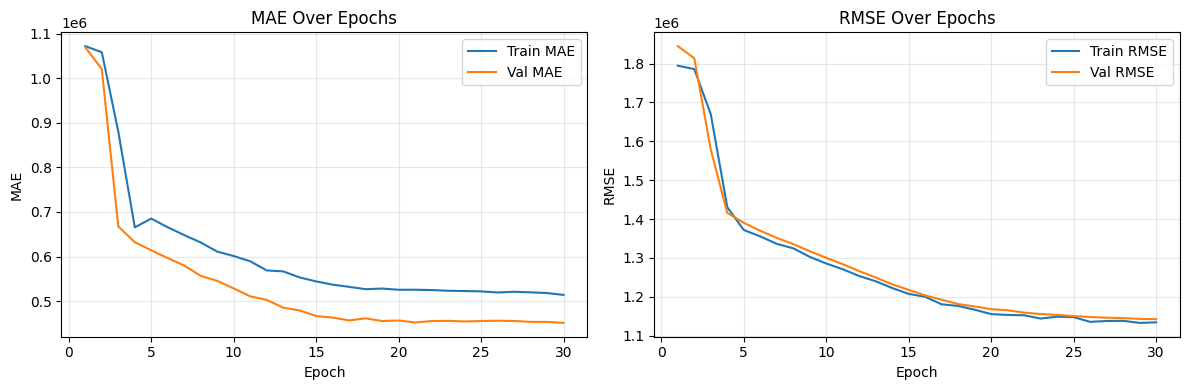

In [72]:
from matplotlib import pyplot as plt

%matplotlib inline

epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE over epochs
axes[0].plot(epochs, history.history["mae"], label="Train MAE")
axes[0].plot(epochs, history.history["val_mae"], label="Val MAE")
axes[0].set_title("MAE Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE over epochs
axes[1].plot(epochs, history.history["rmse"], label="Train RMSE")
axes[1].plot(epochs, history.history["val_rmse"], label="Val RMSE")
axes[1].set_title("RMSE Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Holdout metrics - training_model:
  mae: 456960.1250
  rmse: 1158565.8750

Holdout metrics - inference_model:
  mae: 456960.1250
  rmse: 1158565.8750


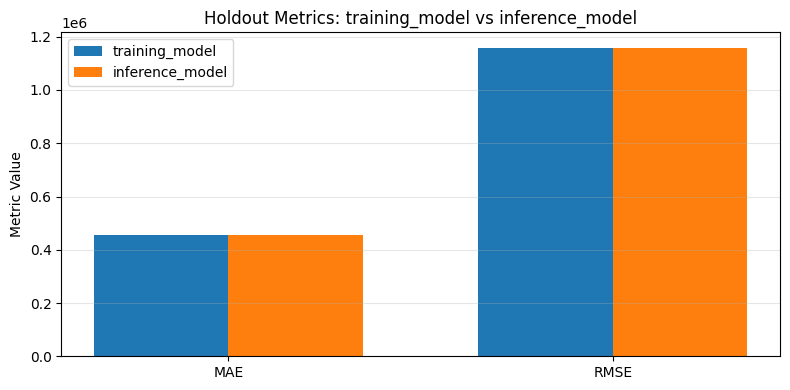

In [76]:
# Compare holdout performance: training_model (encoded input path) vs inference_model (raw input path).
# Compute MAE/RMSE directly from predictions to avoid metric-name differences across TF/Keras versions.
y_true = y_test.to_numpy().reshape(-1)

y_pred_train = training_model.predict(preprocessed_ds_test, verbose=0).reshape(-1)

# Build raw inference inputs in the exact order expected by the model and cast
# each feature to the proper TensorFlow dtype. This avoids the input-structure
# warning and ensures string/categorical features are handled correctly.
input_name_order = [tensor.name.split(":")[0] for tensor in inference_model.inputs]

X_test_for_inference = []
for name in input_name_order:
    values = X_test[name].to_numpy().reshape(-1, 1)

    if name in categorical_headers:
        tensor = tf.convert_to_tensor(values.astype(str), dtype=tf.string)
    elif name.endswith("_bin"):
        tensor = tf.convert_to_tensor(values, dtype=tf.int64)
    else:
        tensor = tf.convert_to_tensor(values, dtype=tf.float32)

    X_test_for_inference.append(tensor)

y_pred_infer = inference_model.predict(
    X_test_for_inference,
    batch_size=batch_size,
    verbose=0,
).reshape(-1)

train_results = {
    "mae": float(np.mean(np.abs(y_true - y_pred_train))),
    "rmse": float(np.sqrt(np.mean((y_true - y_pred_train) ** 2))),
}
infer_results = {
    "mae": float(np.mean(np.abs(y_true - y_pred_infer))),
    "rmse": float(np.sqrt(np.mean((y_true - y_pred_infer) ** 2))),
}

print("Holdout metrics - training_model:")
for k, v in train_results.items():
    print(f"  {k}: {v:.4f}")

print("\nHoldout metrics - inference_model:")
for k, v in infer_results.items():
    print(f"  {k}: {v:.4f}")

# Plot MAE and RMSE comparison across both models on holdout data.
metrics_to_plot = ["mae", "rmse"]
x = np.arange(len(metrics_to_plot))
width = 0.35

train_vals = [train_results[m] for m in metrics_to_plot]
infer_vals = [infer_results[m] for m in metrics_to_plot]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, train_vals, width, label="training_model")
ax.bar(x + width / 2, infer_vals, width, label="inference_model")

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylabel("Metric Value")
ax.set_title("Holdout Metrics: training_model vs inference_model")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Model 1: Visualizations


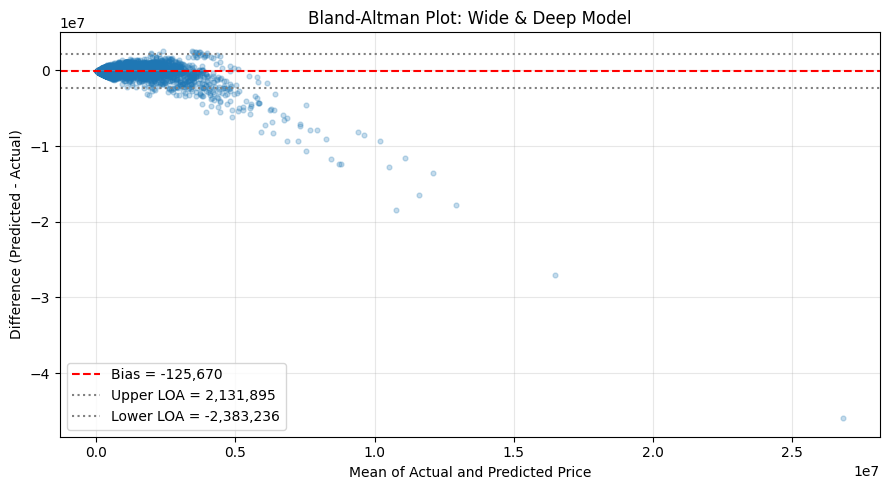

Bias: -125,670.44
Upper limit of agreement: 2,131,894.75
Lower limit of agreement: -2,383,235.75


In [81]:
# Bland-Altman plot for the current regression model.
# We define the difference as (predicted - actual) so positive values mean
# overprediction and negative values mean underprediction, matching the
# percent-error plot sign convention.
actual = y_true.reshape(-1)
predicted = y_pred_infer.reshape(-1)

mean_vals = (actual + predicted) / 2
diff_vals = predicted - actual

bias = diff_vals.mean()
sd = diff_vals.std(ddof=1)
loa_upper = bias + 1.96 * sd
loa_lower = bias - 1.96 * sd

plt.figure(figsize=(9, 5))
plt.scatter(mean_vals, diff_vals, alpha=0.25, s=12)
plt.axhline(bias, color="red", linestyle="--", label=f"Bias = {bias:,.0f}")
plt.axhline(loa_upper, color="gray", linestyle=":", label=f"Upper LOA = {loa_upper:,.0f}")
plt.axhline(loa_lower, color="gray", linestyle=":", label=f"Lower LOA = {loa_lower:,.0f}")

plt.title("Bland-Altman Plot: Wide & Deep Model")
plt.xlabel("Mean of Actual and Predicted Price")
plt.ylabel("Difference (Predicted - Actual)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Bias: {bias:,.2f}")
print(f"Upper limit of agreement: {loa_upper:,.2f}")
print(f"Lower limit of agreement: {loa_lower:,.2f}")

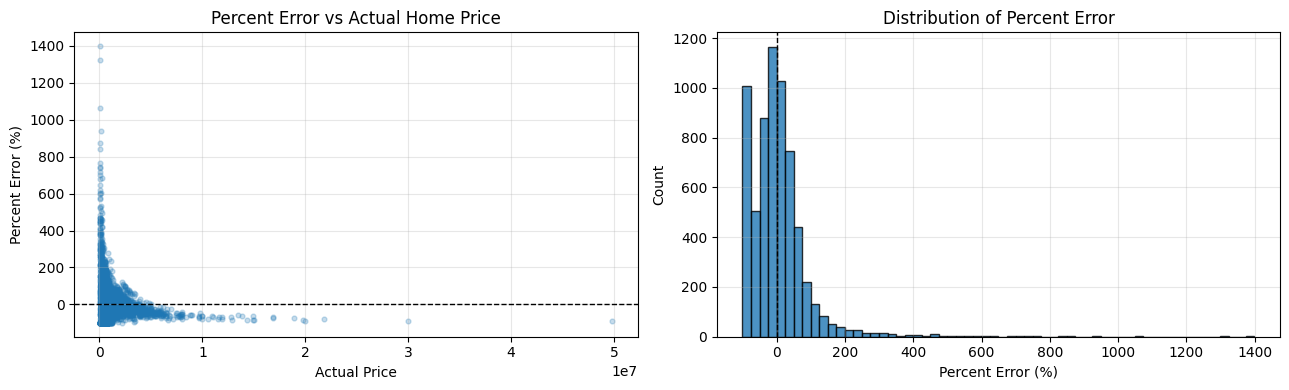

Median absolute percent error: 39.82%
Mean absolute percent error: 56.11%


In [80]:
# Additional diagnostic: percent error relative to the actual home price.
# Here we define percent error so positive values mean the model OVER-predicted
# relative to the actual price, and negative values mean it UNDER-predicted.
percent_error = 100.0 * (y_pred_infer - y_true) / np.maximum(np.abs(y_true), 1e-8)
abs_percent_error = np.abs(percent_error)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatterplot of percent error vs actual price.
axes[0].scatter(y_true, percent_error, alpha=0.25, s=12)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Percent Error vs Actual Home Price')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Percent Error (%)')
axes[0].grid(True, alpha=0.3)

# Histogram of percent error to show spread and skew.
axes[1].hist(percent_error, bins=60, edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribution of Percent Error')
axes[1].set_xlabel('Percent Error (%)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Median absolute percent error: {np.median(abs_percent_error):.2f}%")
print(f"Mean absolute percent error: {np.mean(abs_percent_error):.2f}%")

#### Model 1: Explanation

The **Bland–Altman** plot for Model 1 shows the agreement between predicted and actual
home prices by plotting residual error against the mean price.
The `y-axis` shows the residual error, the `actual - predicted` difference.
The `x-axis` shows the avg of the actual and predicted values, higher priced homes further right.

This model shows predictions which are reasonably centered around the true values, especially
for the lower priced homes, under $500k. This plot **does** show that this model degrades as
home price gets larger. Interestingly, our prediction error increases in a linear manner as
home prices increase, especially > $500k.

The limits of agreement (LOA) are relatively wide, indicating substantial variability in
prediction error. This suggests that while the model may capture overall pricing patterns,
it can still overestimate or underestimate individual homes by a large amount,
especially at the higher end of the market.

In general, we're disappointed that our residuals aren't smaller.

Look at some **percent error** plots, the histogram seems to show we're underpredicting more than overpredicting.
But, the **percent error** scatter plot suggests we're overpredicting many lower priced homes, 
while we're generally underpredicting higher priced homes. We need to improve this.

### Model 2

#### Model 2: Visualizations

#### Model 2: Explanation

### Model 3

#### Model 3: Visualizations


#### Model 3: Explanation

## Exceptional Work

### Arturo update: model-depth comparison and regression evaluation

To match the Lab 5 rubric, this section extends the existing regression wide-and-deep workflow by:

1. Training additional wide-and-deep variants with different numbers of hidden layers in the deep branch.
2. Comparing those variants against the MLP baseline.
3. Using regression-focused evaluation, including residual variance and Bland-Altman style analysis.

This directly addresses the rubric requirements for:
- at least three combined wide and deep networks,
- altering the number of layers in the deep branch,
- and comparing the best wide and deep model to a standard MLP for a regression task.


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout, Concatenate
import matplotlib.pyplot as plt


def build_wd_from_encoded(encoded_features, feature_space, numeric_headers, categorical_headers, hidden_units):
    from tensorflow.keras.layers import Embedding, Flatten

    def setup_embedding_from_encoding_crossing(encoded_features, feature_space, col_name):
        x = encoded_features[col_name]
        N = feature_space.crossers[col_name].num_bins
        N_embed = int(np.ceil(np.sqrt(N)))
        x = Embedding(input_dim=N, output_dim=N_embed, name=f"{col_name}_embed")(x)
        x = Flatten()(x)
        return x

    def setup_embedding_from_encoding_categorical(encoded_features, feature_space, col_name):
        x = encoded_features[col_name]
        N = len(feature_space.preprocessors[col_name].get_vocabulary())
        N_embed = int(np.ceil(np.sqrt(N)))
        x = Embedding(input_dim=N, output_dim=N_embed, name=f"{col_name}_embed")(x)
        x = Flatten()(x)
        return x

    crossed_outputs = []
    for col in feature_space.crossers.keys():
        crossed_outputs.append(
            setup_embedding_from_encoding_crossing(encoded_features, feature_space, col)
        )
    wide_branch = Concatenate(name=f'wide_concat_{"_".join(map(str, hidden_units))}')(crossed_outputs)

    deep_parts = []
    numeric_headers = [col for col in numeric_headers if col in encoded_features]
    for col in numeric_headers:
        deep_parts.append(encoded_features[col])

    for col in categorical_headers:
        deep_parts.append(
            setup_embedding_from_encoding_categorical(encoded_features, feature_space, col)
        )

    used_feature_keys = set(feature_space.crossers.keys()) | set(numeric_headers) | set(categorical_headers)
    for col in encoded_features.keys():
        if col not in used_feature_keys:
            deep_parts.append(encoded_features[col])

    deep_branch = Concatenate(name=f'embed_concat_{"_".join(map(str, hidden_units))}')(deep_parts)

    for i, units in enumerate(hidden_units, start=1):
        deep_branch = Dense(
            units=units,
            activation='relu',
            name=f'deep_{len(hidden_units)}layers_{i}'
        )(deep_branch)
        deep_branch = Dropout(0.2, name=f'dropout_{len(hidden_units)}layers_{i}')(deep_branch)

    final_branch = Concatenate(name=f'concat_deep_wide_{"_".join(map(str, hidden_units))}')(
        [deep_branch, wide_branch]
    )
    output = Dense(
        units=1,
        activation='linear',
        name=f'predicted_price_{"_".join(map(str, hidden_units))}'
    )(final_branch)

    model = Model(inputs=encoded_features, outputs=output)
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model


variant_specs = {
    "wd_1layer": [32],
    "wd_2layer": [64, 32],
    "wd_3layer": [64, 32, 16],
}

wd_results = []
wd_histories = {}
wd_predictions = {}

for model_name, hidden_units in variant_specs.items():
    print(f"Training {model_name} with hidden units {hidden_units}")
    model = build_wd_from_encoded(
        encoded_features, feature_space, continuous_numeric_headers, categorical_headers, hidden_units
    )

    history = model.fit(
        preprocessed_ds_train,
        validation_data=preprocessed_ds_val,
        epochs=10,
        verbose=1,
    )

    preds = model.predict(preprocessed_ds_test, verbose=0).reshape(-1)
    residuals = y_test.to_numpy().reshape(-1) - preds

    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    resid_var = np.var(residuals, ddof=1)

    wd_histories[model_name] = history.history
    wd_predictions[model_name] = preds
    wd_results.append(
        {
            "model": model_name,
            "layers": len(hidden_units),
            "hidden_units": str(hidden_units),
            "mae": float(mae),
            "rmse": float(rmse),
            "residual_variance": float(resid_var),
        }
    )

wd_results_df = pd.DataFrame(wd_results).sort_values("rmse").reset_index(drop=True)
display(wd_results_df)

best_wd_name = wd_results_df.loc[0, "model"]
best_wd_preds = wd_predictions[best_wd_name]

print(f"Best wide/deep model: {best_wd_name}")

plt.figure(figsize=(8, 5))
for model_name, hist in wd_histories.items():
    plt.plot(hist["val_loss"], label=f"{model_name} val_loss")
plt.title("Validation Loss Across Wide & Deep Variants")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

residuals_best = y_test.to_numpy().reshape(-1) - best_wd_preds
means_best = (y_test.to_numpy().reshape(-1) + best_wd_preds) / 2

plt.figure(figsize=(8, 5))
plt.scatter(means_best, residuals_best, alpha=0.35)
plt.axhline(np.mean(residuals_best), linestyle='--')
plt.axhline(np.mean(residuals_best) + 1.96 * np.std(residuals_best), linestyle=':')
plt.axhline(np.mean(residuals_best) - 1.96 * np.std(residuals_best), linestyle=':')
plt.title(f"Bland-Altman Style Plot: {best_wd_name}")
plt.xlabel("Mean of Actual and Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

Training wd_1layer with hidden units [32]


NameError: name 'encoded_features' is not defined